# Wind/Solar Impact on Prices -- DK1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from da_forecast.sources.cache import ParquetCache
from da_forecast.config import RAW_DIR

cache = ParquetCache(RAW_DIR)

prices = cache.load("energinet", "DK_1", "day_ahead_prices")[["price_eur_mwh"]]
wind_solar = cache.load("energinet", "DK_1", "wind_solar_forecast")
load = cache.load("energinet", "DK_1", "load_forecast")

df = prices.join(wind_solar, how="inner").join(load, how="inner")
df["wind_total_mw"] = df["wind_onshore_mw"] + df["wind_offshore_mw"]
df["renewable_mw"] = df["wind_total_mw"] + df["solar_mw"]
df["residual_load_mw"] = df["load_mw"] - df["renewable_mw"]
df.index = df.index.tz_convert("Europe/Copenhagen")
df["hour"] = df.index.hour
df["month"] = df.index.month

print(f"{len(df)} hours, {df.index.min()} to {df.index.max()}")

8728 hours, 2024-10-01 02:00:00+02:00 to 2025-09-30 23:00:00+02:00


### Wind vs Price
Merit order effect visible but moderate. Correlation around -0.4 for DK1, not the -0.7 to -0.9 sometimes cited for single-fuel markets. Interconnector flows and coupled clearing dilute the effect.

Wind-price correlation: -0.399


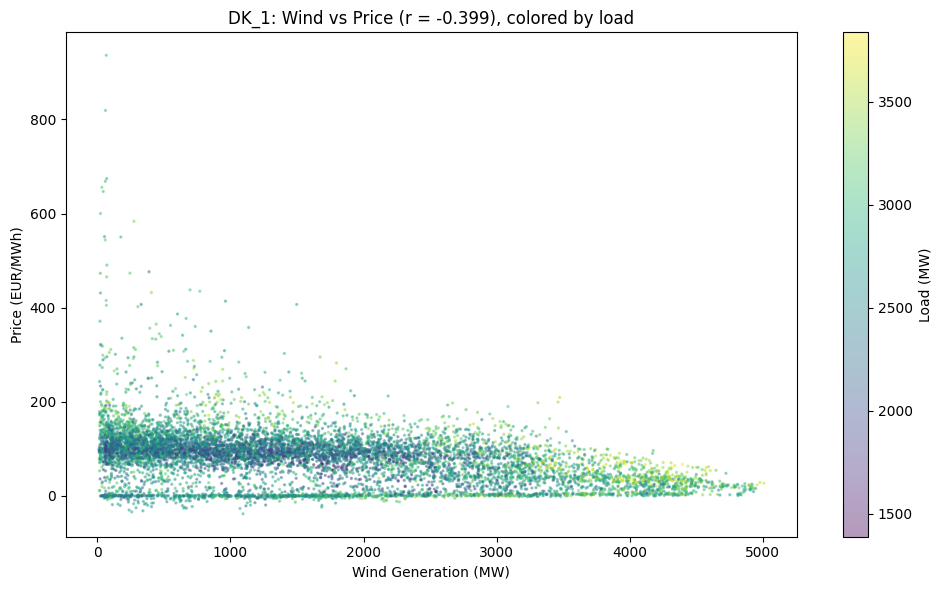

In [2]:
corr = df["wind_total_mw"].corr(df["price_eur_mwh"])
print(f"Wind-price correlation: {corr:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df["wind_total_mw"], df["price_eur_mwh"],
                c=df["load_mw"], cmap="viridis", s=2, alpha=0.4)
plt.colorbar(sc, ax=ax, label="Load (MW)")
ax.set_xlabel("Wind Generation (MW)")
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title(f"DK_1: Wind vs Price (r = {corr:.3f}), colored by load")
fig.tight_layout()
plt.show()

### Binned Wind-Price Curve
Non-linear relationship. Price suppression accelerates above ~3000 MW wind (roughly where DK1 starts exporting heavily).

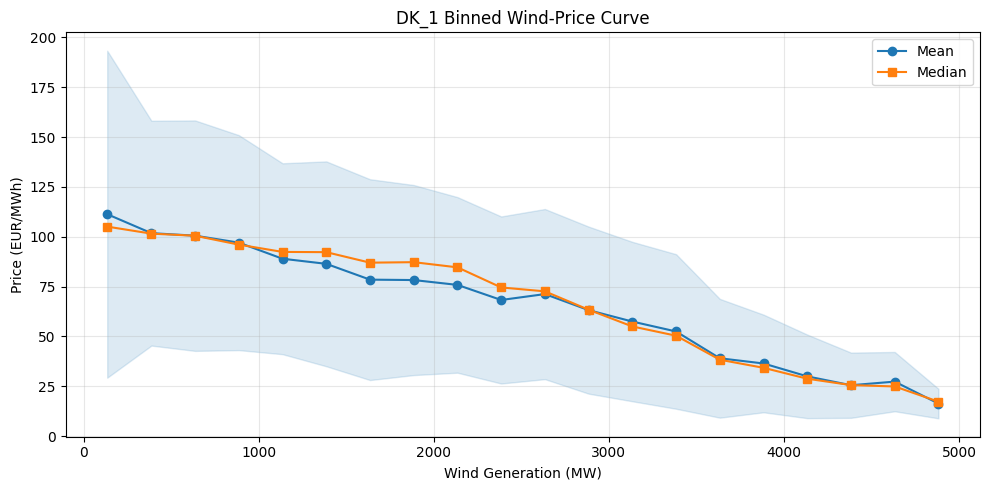

In [3]:
df["wind_bin"] = pd.cut(df["wind_total_mw"], bins=20)
binned = df.groupby("wind_bin", observed=True)["price_eur_mwh"].agg(["mean", "median", "std", "count"])
binned["mid"] = binned.index.map(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(binned["mid"], binned["mean"], marker="o", label="Mean", color="#1f77b4")
ax.plot(binned["mid"], binned["median"], marker="s", label="Median", color="#ff7f0e")
ax.fill_between(binned["mid"],
                binned["mean"] - binned["std"],
                binned["mean"] + binned["std"],
                alpha=0.15, color="#1f77b4")
ax.set_xlabel("Wind Generation (MW)")
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title("DK_1 Binned Wind-Price Curve")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Solar Duck Curve -- Summer vs Spring
Denmark's solar capacity is modest compared to DE_LU, but the coupled market means the German solar duck curve propagates into DK prices.

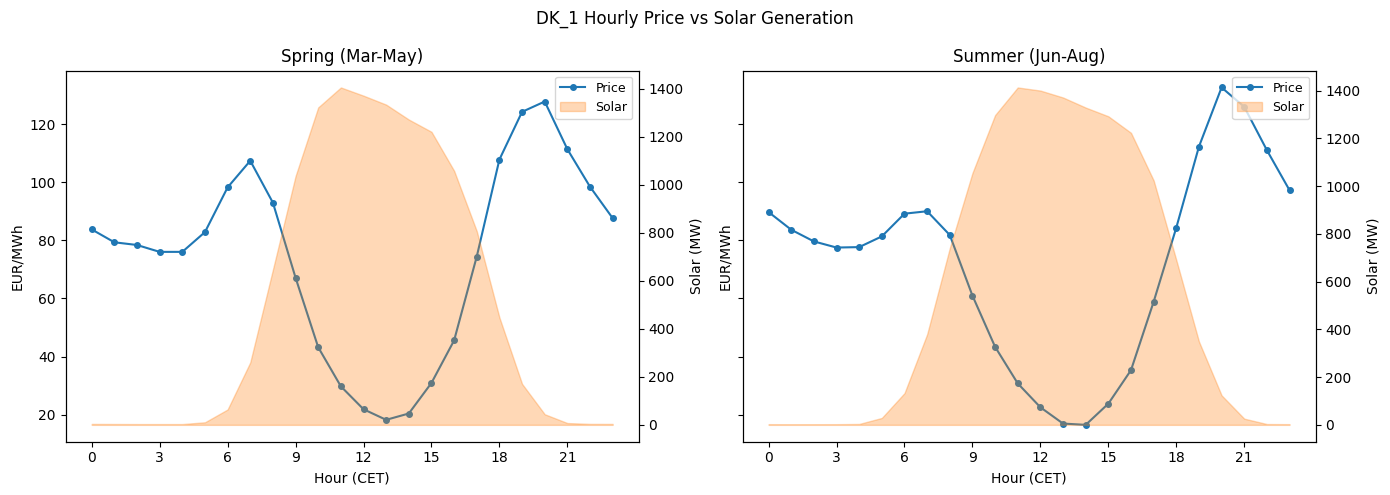

In [4]:
summer = df[df["month"].isin([6, 7, 8])]
spring = df[df["month"].isin([3, 4, 5])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, season, label in [(axes[0], spring, "Spring (Mar-May)"), (axes[1], summer, "Summer (Jun-Aug)")]:
    hourly_price = season.groupby("hour")["price_eur_mwh"].mean()
    hourly_solar = season.groupby("hour")["solar_mw"].mean()

    ax2 = ax.twinx()
    ax.plot(hourly_price.index, hourly_price.values, color="#1f77b4", marker="o", markersize=4, label="Price")
    ax2.fill_between(hourly_solar.index, 0, hourly_solar.values, alpha=0.3, color="#ff7f0e", label="Solar")
    ax.set_xlabel("Hour (CET)")
    ax.set_ylabel("EUR/MWh")
    ax2.set_ylabel("Solar (MW)")
    ax.set_title(label)
    ax.set_xticks(range(0, 24, 3))

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)

fig.suptitle("DK_1 Hourly Price vs Solar Generation", fontsize=12)
fig.tight_layout()
plt.show()

### Residual Load as Primary Driver
Residual load (load minus wind minus solar) is a stronger price predictor than any individual generation type. This is the single most important fundamental feature.

Correlation with price:
price_eur_mwh       1.000
load_mw            -0.007
wind_total_mw      -0.399
solar_mw           -0.341
residual_load_mw    0.586
Name: price_eur_mwh, dtype: float64


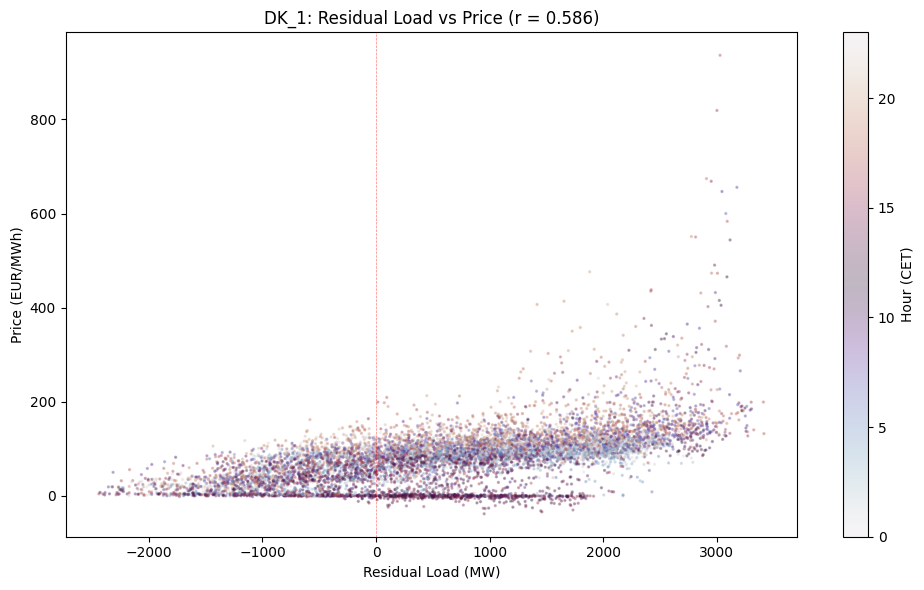

In [5]:
corr_matrix = df[["price_eur_mwh", "load_mw", "wind_total_mw", "solar_mw", "residual_load_mw"]].corr()
print("Correlation with price:")
print(corr_matrix["price_eur_mwh"].round(3))

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df["residual_load_mw"], df["price_eur_mwh"], s=2, alpha=0.3, c=df["hour"], cmap="twilight")
plt.colorbar(sc, ax=ax, label="Hour (CET)")
ax.set_xlabel("Residual Load (MW)")
ax.set_ylabel("Price (EUR/MWh)")
r = df["residual_load_mw"].corr(df["price_eur_mwh"])
ax.set_title(f"DK_1: Residual Load vs Price (r = {r:.3f})")
ax.axvline(0, color="red", linewidth=0.5, linestyle="--", alpha=0.5)
fig.tight_layout()
plt.show()

### Extreme Event Conditions
What market conditions produce the top/bottom 1% of prices? Useful for understanding tail risk and setting forecast confidence bands.

Thresholds: bottom 1% <= -5.2 EUR/MWh, top 1% >= 256.2 EUR/MWh
Bottom 1%: 88 hours, Top 1%: 88 hours



,Bottom 1%,Middle 98%,Top 1%
price_eur_mwh,-12.9,80.0,370.7
wind_total_mw,939.9,1651.8,477.7
solar_mw,902.3,356.8,57.8
load_mw,2816.3,2652.1,3031.2
residual_load_mw,974.2,643.5,2495.7


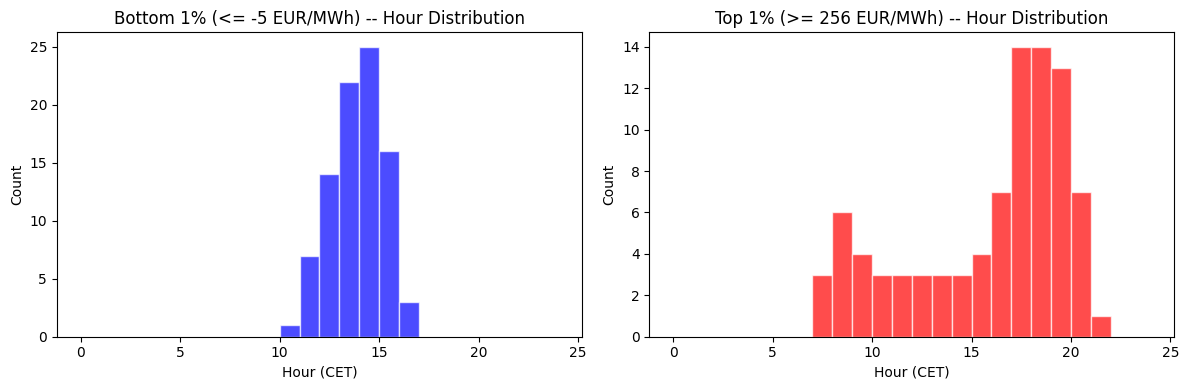

In [6]:
p01 = df["price_eur_mwh"].quantile(0.01)
p99 = df["price_eur_mwh"].quantile(0.99)

bottom_1 = df[df["price_eur_mwh"] <= p01]
top_1 = df[df["price_eur_mwh"] >= p99]
middle = df[(df["price_eur_mwh"] > p01) & (df["price_eur_mwh"] < p99)]

cols = ["price_eur_mwh", "wind_total_mw", "solar_mw", "load_mw", "residual_load_mw"]

summary = pd.DataFrame({
    "Bottom 1%": bottom_1[cols].mean(),
    "Middle 98%": middle[cols].mean(),
    "Top 1%": top_1[cols].mean(),
}).round(1)

print(f"Thresholds: bottom 1% <= {p01:.1f} EUR/MWh, top 1% >= {p99:.1f} EUR/MWh")
print(f"Bottom 1%: {len(bottom_1)} hours, Top 1%: {len(top_1)} hours\n")
display(summary)

# Hour distribution for extremes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(bottom_1["hour"], bins=range(25), color="blue", alpha=0.7, edgecolor="white")
axes[0].set_title(f"Bottom 1% (<= {p01:.0f} EUR/MWh) -- Hour Distribution")
axes[0].set_xlabel("Hour (CET)")
axes[0].set_ylabel("Count")

axes[1].hist(top_1["hour"], bins=range(25), color="red", alpha=0.7, edgecolor="white")
axes[1].set_title(f"Top 1% (>= {p99:.0f} EUR/MWh) -- Hour Distribution")
axes[1].set_xlabel("Hour (CET)")
axes[1].set_ylabel("Count")

fig.tight_layout()
plt.show()